Calculando F1-Score automaticamente...
Salvando gráfico em portfolio_metrics_distribution_lag1.pdf...


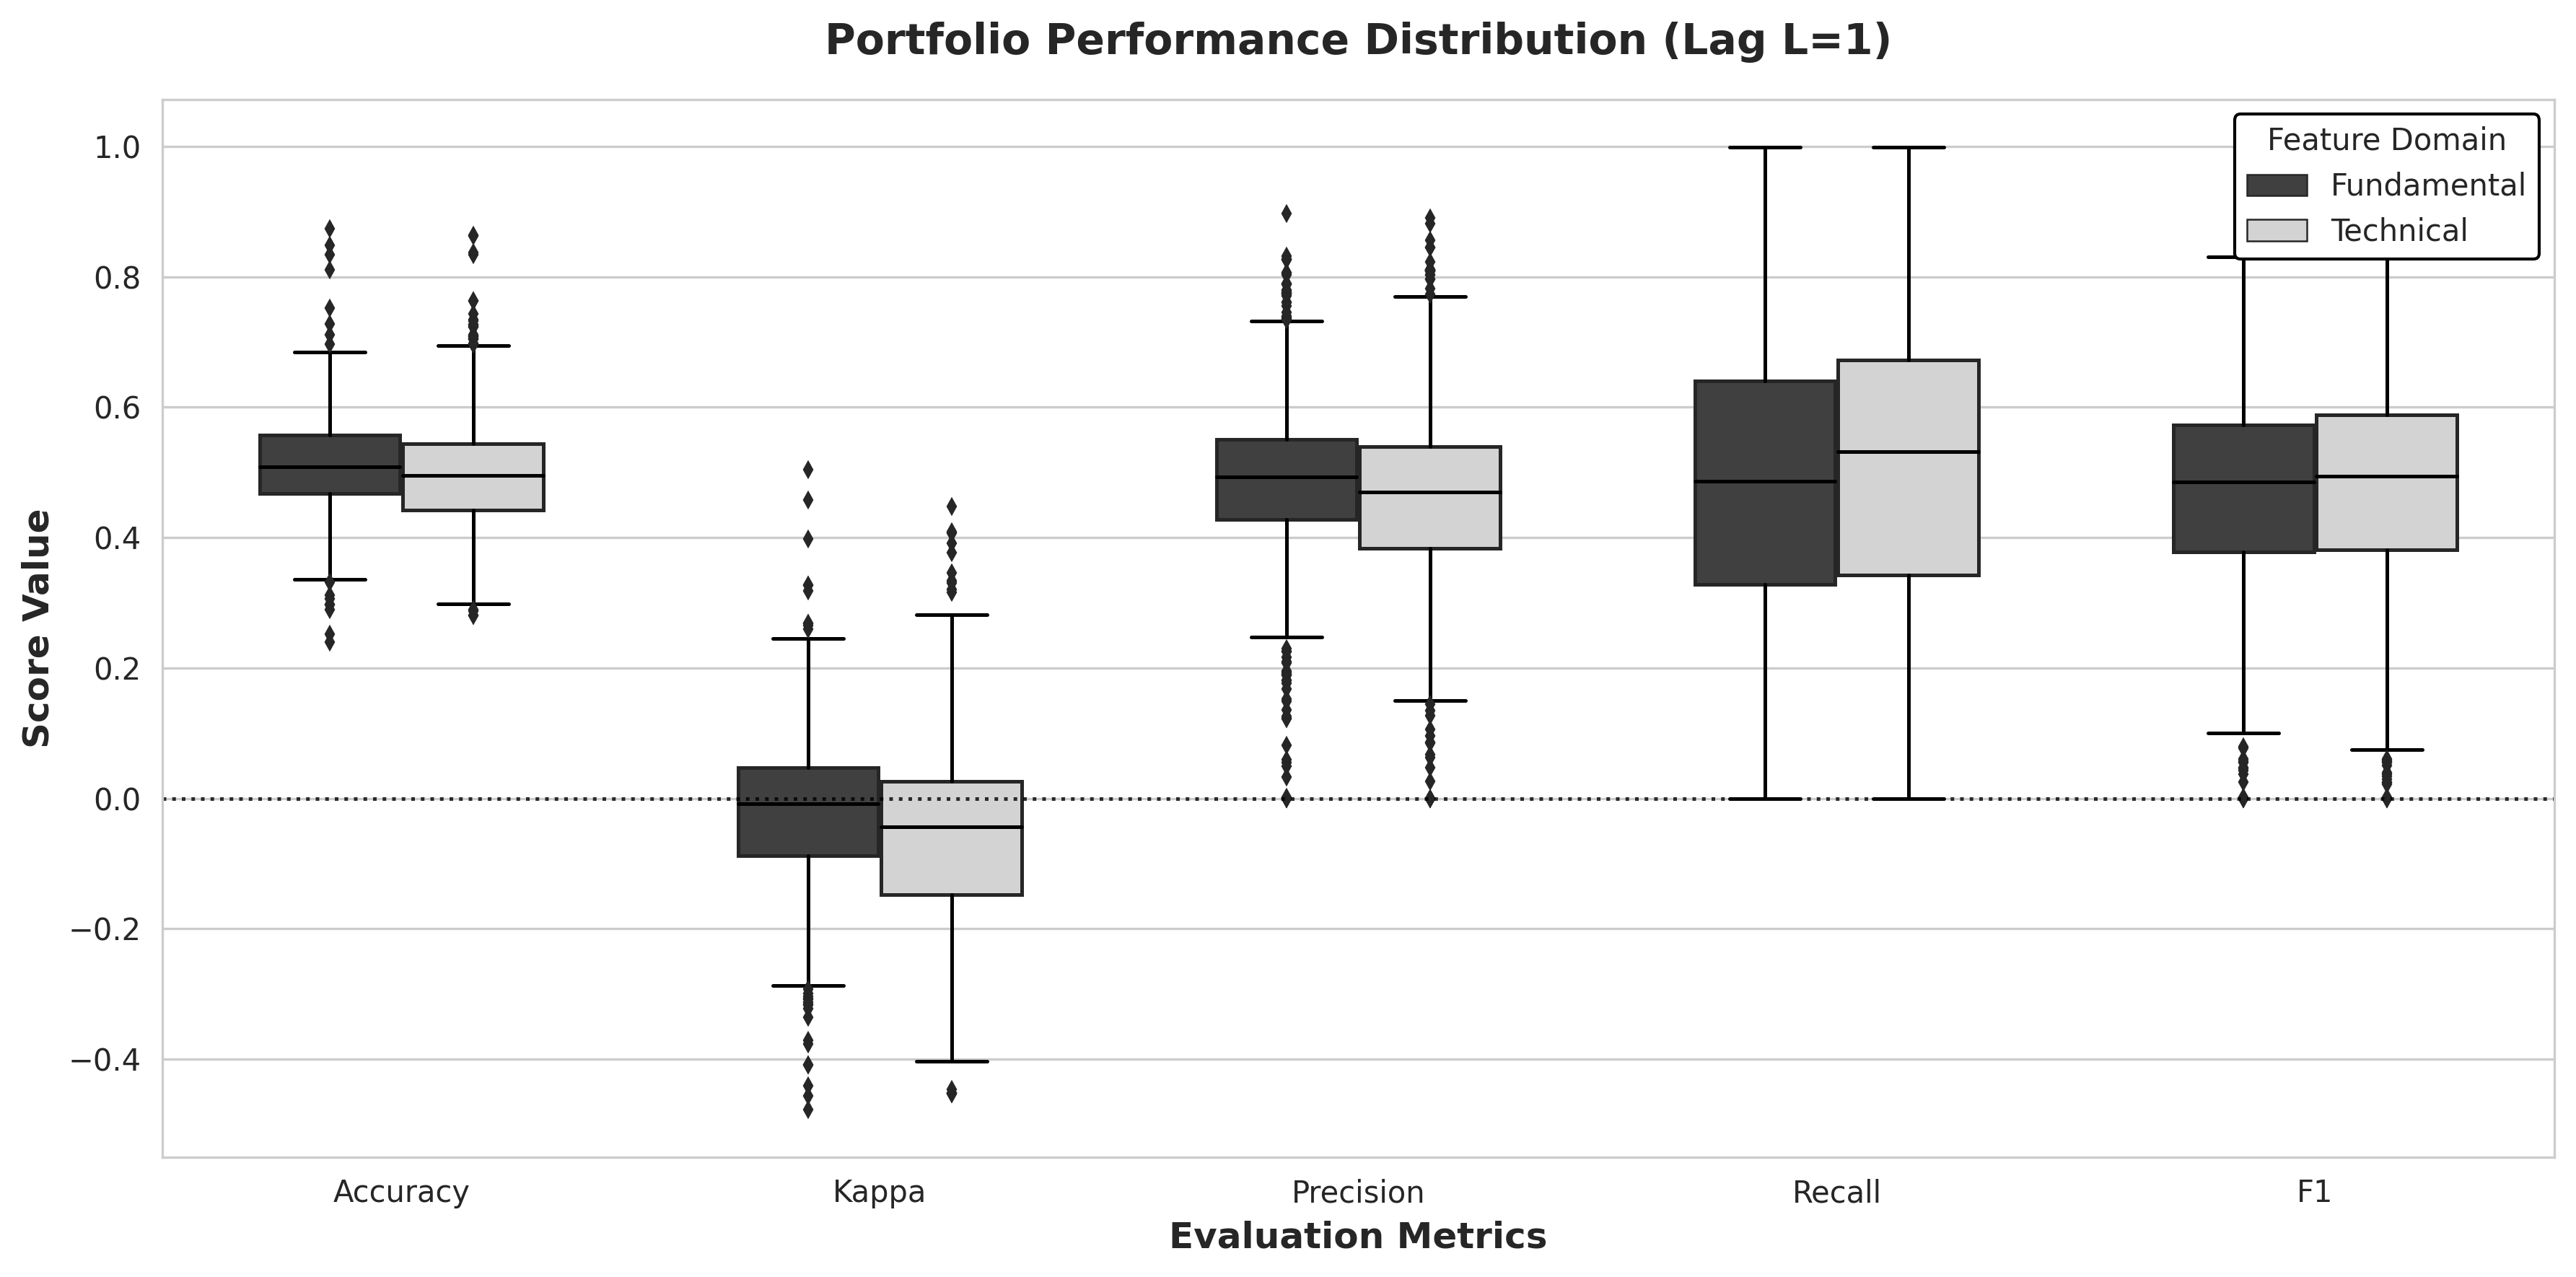

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# ==============================================================================
# 1. CONFIGURAÇÕES
# ==============================================================================
modelo = 'HT'
atraso_selecionado = 1 
caminho_base = 'resultados'
nome_arquivo_saida = f'portfolio_metrics_distribution_lag{atraso_selecionado}.pdf'

mapa_nomes = {'fund': 'Fundamental', 'nao_fund': 'Technical'}
palette_pb = {'Fundamental': '#404040', 'Technical': '#D3D3D3'} 

# ==============================================================================
# 2. CARREGAMENTO E LIMPEZA (A CORREÇÃO ESTÁ AQUI)
# ==============================================================================
nome_arquivo = f'resultados_{modelo}_atraso_{atraso_selecionado}.csv'
caminho_completo = os.path.join(caminho_base, nome_arquivo)

try:
    # 1. Carregar dados
    if os.path.exists(caminho_completo):
        df = pd.read_csv(caminho_completo)
    else:
        # Mock para teste (caso sem arquivo)
        print("AVISO: Arquivo não encontrado. Usando dados aleatórios.")
        data = []
        for cat in ['fund', 'nao_fund']:
            for _ in range(58):
                acc = np.random.normal(0.52 if cat=='fund' else 0.50, 0.02)
                data.append({
                    'categoria': cat, 
                    'Accuracy': acc, 
                    'Kappa': (acc-0.5)*2, 
                    'Precision': acc-0.01, 
                    'Recall': acc+0.01
                })
        df = pd.DataFrame(data)

    # 2. FUNÇÃO DE LIMPEZA DE DADOS (CRUCIAL)
    # Converte colunas numéricas que podem estar como texto ('0,50') para float (0.50)
    cols_numericas = ['Accuracy', 'Kappa', 'Precision', 'Recall', 'F1']
    
    for col in cols_numericas:
        if col in df.columns:
            # Se for do tipo object (string), substitui vírgula por ponto
            if df[col].dtype == 'object':
                df[col] = df[col].astype(str).str.replace(',', '.')
            
            # Força conversão para número (erros viram NaN)
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # 3. CÁLCULO SEGURO DO F1-SCORE
    if 'F1' not in df.columns:
        if 'Precision' in df.columns and 'Recall' in df.columns:
            print("Calculando F1-Score automaticamente...")
            # Agora garantimos que são números floats
            df['F1'] = 2 * (df['Precision'] * df['Recall']) / (df['Precision'] + df['Recall'] + 1e-9)
        else:
            print("AVISO: Colunas Precision/Recall ausentes. F1 não calculado.")

    # 4. PREPARAR PARA PLOTAGEM
    metricas_finais = [m for m in cols_numericas if m in df.columns]
    
    # Mapear nomes
    df['Domain'] = df['categoria'].map(mapa_nomes)
    df_plot = df[df['Domain'].notna()].copy()

    # Melt (Transformar em formato longo para o Seaborn)
    df_melted = df_plot.melt(
        id_vars=['Domain'], 
        value_vars=metricas_finais,
        var_name='Metric', 
        value_name='Score'
    )

    # ==============================================================================
    # 3. PLOTAGEM
    # ==============================================================================
    sns.set_style("whitegrid")
    plt.figure(figsize=(12, 6), dpi=300)

    ax = sns.boxplot(
        data=df_melted,
        x='Metric', y='Score', hue='Domain',
        palette=palette_pb,
        linewidth=1.2, fliersize=3, width=0.6
    )

    # Corrigir cor da mediana
    for line in ax.lines:
        line.set_color('black')

    plt.title(f'Portfolio Performance Distribution (Lag L={atraso_selecionado})', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Evaluation Metrics', fontsize=12, fontweight='bold')
    plt.ylabel('Score Value', fontsize=12, fontweight='bold')
    
    # Linha zero
    plt.axhline(0, color='black', linestyle=':', linewidth=1.2, alpha=0.8)
    
    plt.legend(title='Feature Domain', title_fontsize=10, fontsize=10, 
               loc='upper right', frameon=True, framealpha=1, edgecolor='black')

    plt.tight_layout()
    print(f"Salvando gráfico em {nome_arquivo_saida}...")
    plt.savefig(nome_arquivo_saida, format='pdf', bbox_inches='tight')
    plt.show()

except Exception as e:
    print("="*50)
    print(f"ERRO TRATADO: {e}")
    print("Verifique se seu CSV usa vírgula ou ponto para decimais.")
    print("="*50)

Sucesso! Agrupando dados pela coluna: 'base'


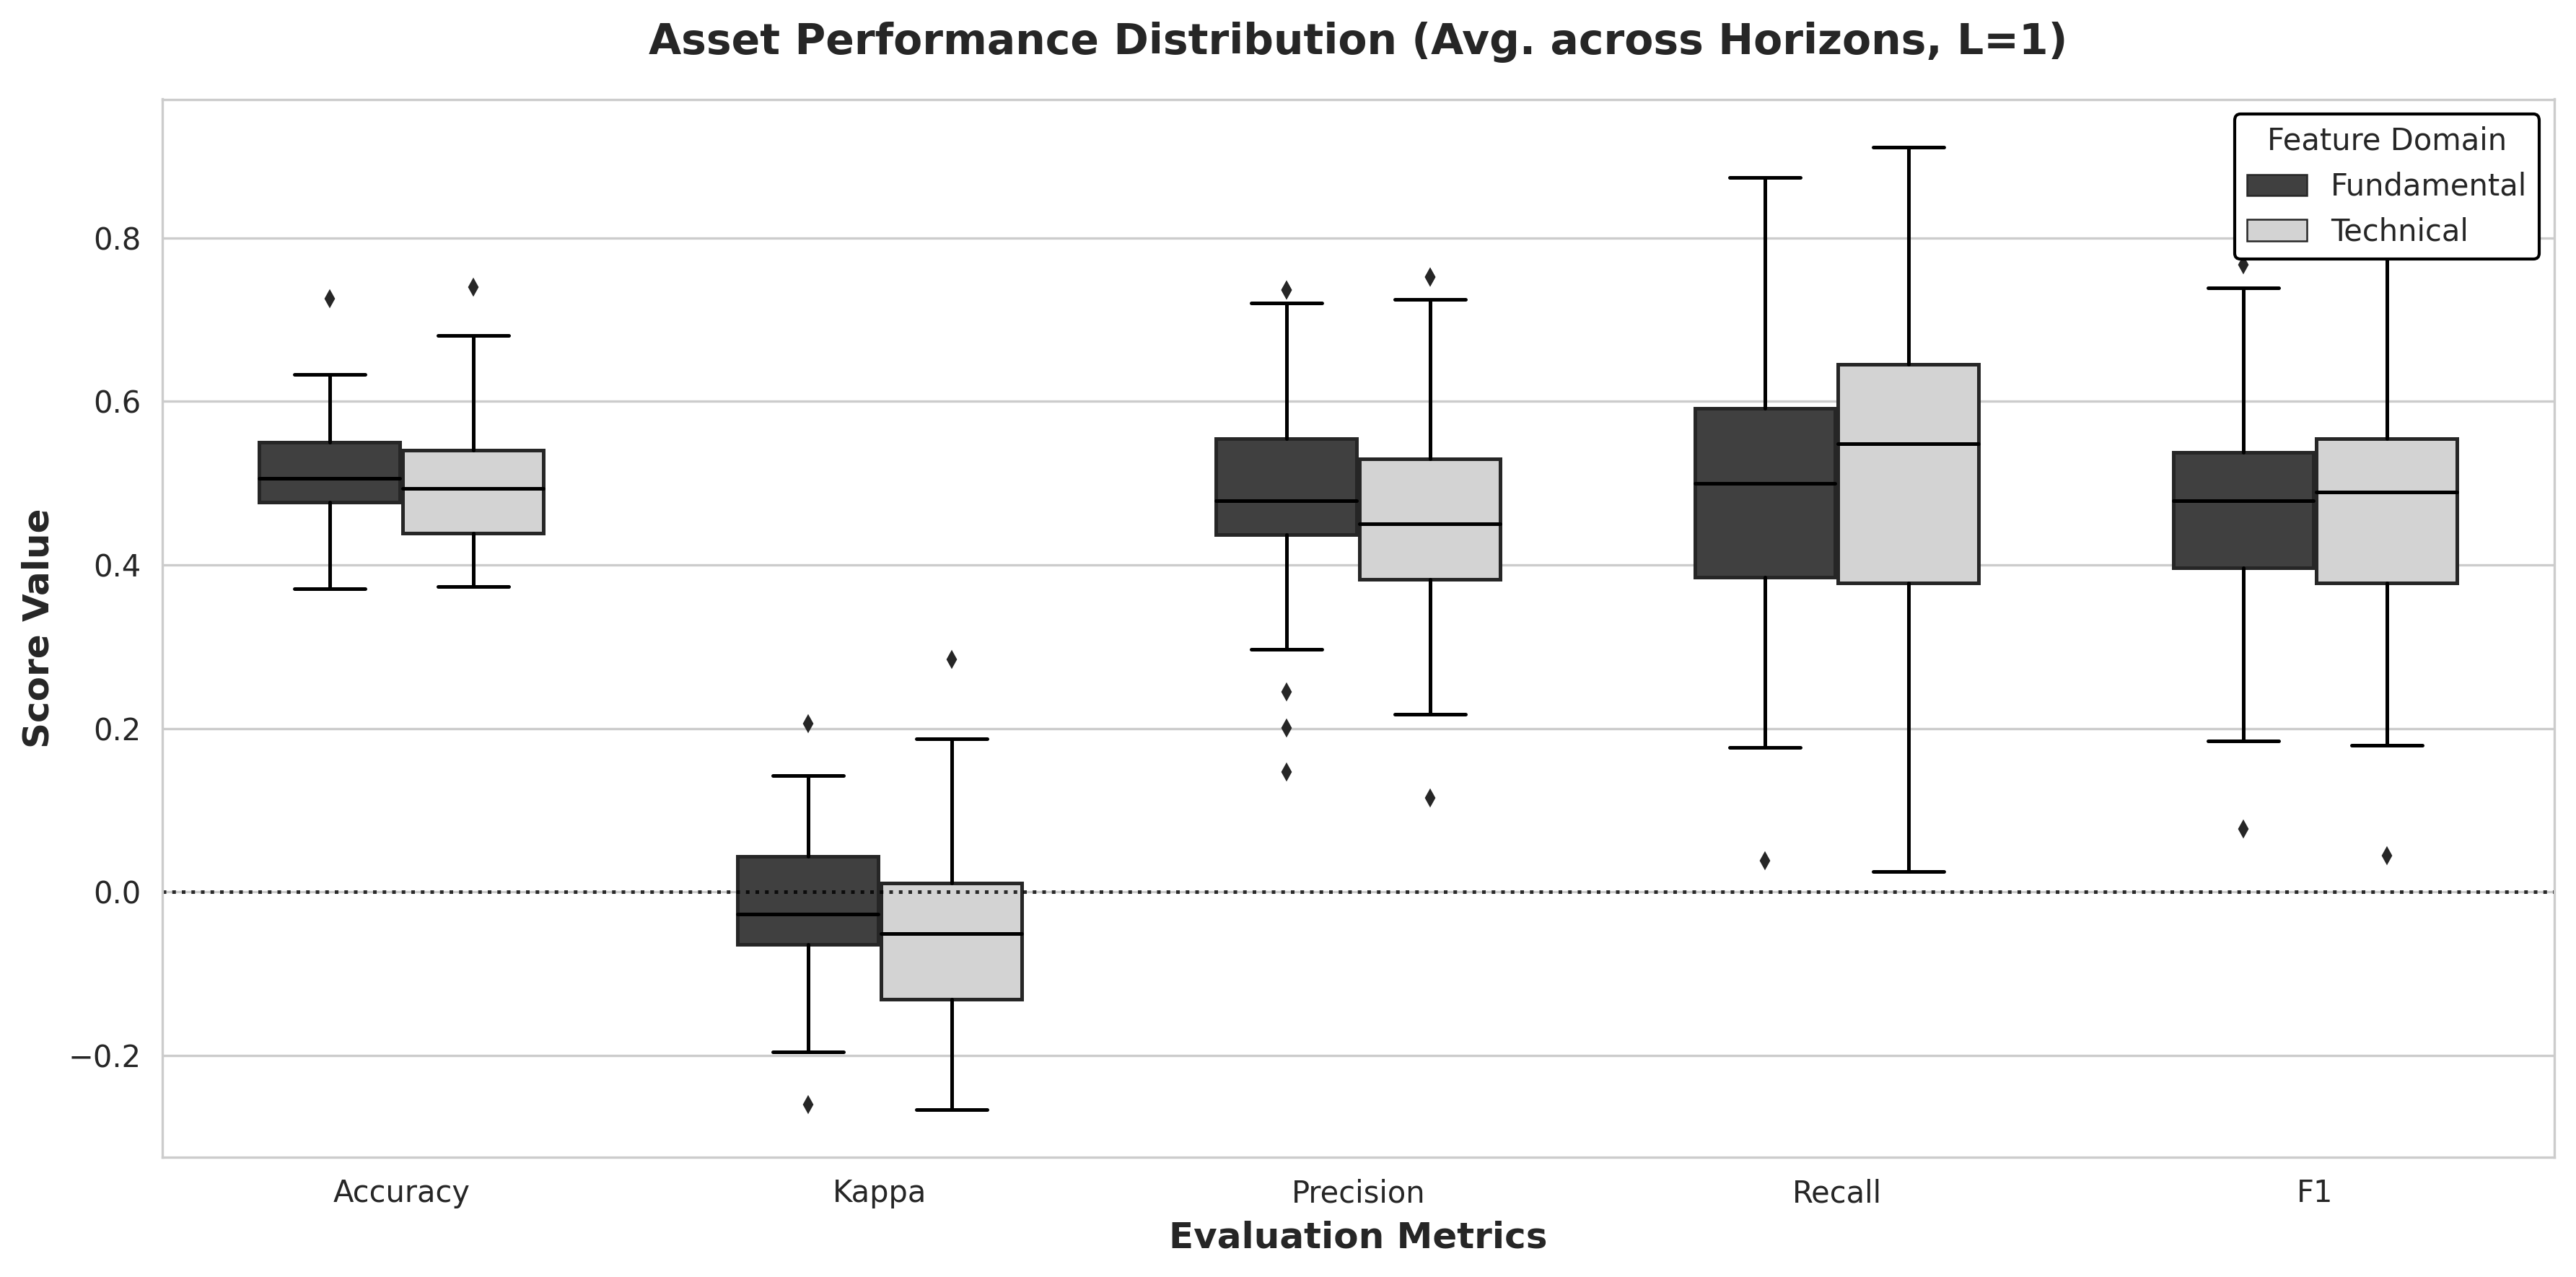

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# ==============================================================================
# 1. CONFIGURAÇÕES
# ==============================================================================
modelo = 'HT'
atraso_selecionado = 1
caminho_base = 'resultados'
nome_arquivo_saida = 'portfolio_metrics_final.pdf'

mapa_nomes = {'fund': 'Fundamental', 'nao_fund': 'Technical'}
palette_pb = {'Fundamental': '#404040', 'Technical': '#D3D3D3'} 

# ==============================================================================
# 2. CARREGAMENTO
# ==============================================================================
nome_arquivo = f'resultados_{modelo}_atraso_{atraso_selecionado}.csv'
caminho_completo = os.path.join(caminho_base, nome_arquivo)

if not os.path.exists(caminho_completo):
    print("ERRO: Arquivo não encontrado.")
    exit()

df = pd.read_csv(caminho_completo)

# Limpeza de decimais (Vírgula -> Ponto)
cols_numericas = ['Accuracy', 'Kappa', 'Precision', 'Recall', 'F1']
for col in cols_numericas:
    if col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].astype(str).str.replace(',', '.')
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Calcular F1 se faltar
if 'F1' not in df.columns and 'Precision' in df.columns:
    df['F1'] = 2 * (df['Precision'] * df['Recall']) / (df['Precision'] + df['Recall'] + 1e-9)

# ==============================================================================
# 3. LÓGICA DE AGRUPAMENTO INTELIGENTE
# ==============================================================================
# Procura por colunas comuns de identificação de ativos
possiveis_ids = ['asset_id', 'ticker', 'symbol', 'ativo', 'stock', 'id', 'base']
coluna_id_encontrada = None

for col in possiveis_ids:
    if col in df.columns:
        coluna_id_encontrada = col
        break

df_plot = None

if coluna_id_encontrada:
    print(f"Sucesso! Agrupando dados pela coluna: '{coluna_id_encontrada}'")
    cols_para_media = [c for c in cols_numericas if c in df.columns]
    # Agrupa por Categoria E Ativo (tira a média dos horizontes)
    df_agrupado = df.groupby(['categoria', coluna_id_encontrada])[cols_para_media].mean().reset_index()
    df_plot = df_agrupado
    titulo_grafico = f'Asset Performance Distribution (Avg. across Horizons, L={atraso_selecionado})'
else:
    print("AVISO: Nenhuma coluna de ID do ativo encontrada.")
    print("-> Plotando distribuição de TODAS as amostras (sem agregação).")
    # Se não tem ID, usamos o DF original. O gráfico terá mais outliers, mas será correto.
    df_plot = df
    titulo_grafico = f'Portfolio Performance Distribution (All Samples, L={atraso_selecionado})'

# Mapeia nomes
df_plot['Domain'] = df_plot['categoria'].map(mapa_nomes)
df_plot = df_plot[df_plot['Domain'].notna()].copy()

# ==============================================================================
# 4. PLOTAGEM
# ==============================================================================
metricas_finais = [m for m in cols_numericas if m in df_plot.columns]

df_melted = df_plot.melt(
    id_vars=['Domain'], 
    value_vars=metricas_finais,
    var_name='Metric', 
    value_name='Score'
)

sns.set_style("whitegrid")
plt.figure(figsize=(12, 6), dpi=300)

ax = sns.boxplot(
    data=df_melted,
    x='Metric', y='Score', hue='Domain',
    palette=palette_pb,
    linewidth=1.2, fliersize=3, width=0.6
)

# Estilização
for line in ax.lines:
    line.set_color('black')

plt.title(titulo_grafico, fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Evaluation Metrics', fontsize=12, fontweight='bold')
plt.ylabel('Score Value', fontsize=12, fontweight='bold')
plt.axhline(0, color='black', linestyle=':', linewidth=1.2, alpha=0.8)

plt.legend(title='Feature Domain', title_fontsize=10, fontsize=10, 
           loc='upper right', frameon=True, framealpha=1, edgecolor='black')

plt.tight_layout()
plt.savefig(nome_arquivo_saida, format='pdf', bbox_inches='tight')
plt.show()